# ℂ-VAE · WandB Runs Analysis



## Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
from PIL import Image
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

def color_state(val):
    if val == 'finished': return 'color: green'
    if val == 'failed':   return 'color: red'
    return 'color: darkorange'

In [2]:
df = pd.read_csv('runs.csv')

rename = {
    'models.model.bottleneck._target_':         'bottleneck_target',
    'models.model.bottleneck.proper':            'bottleneck_proper',
    'models.model.bottleneck.skip_bottleneck':   'skip_bottleneck',
    'models.model.parameters_to_predict':        'params_to_predict',
    'models.model.latent_channels':              'latent_channels',
    'trainer.loss_config.bottleneck.weights.kl': 'kl_weight',
    'trainer.loss_config.spectral.weights.mrstft':'mrstft_weight',
    'trainer.loss_config.mrmel.weights.mrmel':   'mrmel_weight',
    'trainer.optimizer.lr':                      'lr',
    'trainer.trainer.epochs':                    'max_epochs',
    'trainer.trainer.warmup_steps':              'warmup_steps',
}
df = df.rename(columns=rename)
df['runtime_hours'] = df['Runtime'] / 3600

# Inferisci metadati mancanti per run con config NaN
inferred = {
    'COMPLEX proper C=0':                    dict(bottleneck_mode='proper',      kl_weight_inf=1e-4, loss_label='mse_stft'),
    'COMPLEX cholesky softplus':             dict(bottleneck_mode='cholesky',    kl_weight_inf=1e-4, loss_label='mse_stft'),
    'COMPLEX softplus su sigma e tanh su c': dict(bottleneck_mode='improper',    kl_weight_inf=1e-4, loss_label='mse_stft'),
    'seanet COMPLEX cholesky':               dict(bottleneck_mode='cholesky',    kl_weight_inf=1e-4, loss_label='mse_stft'),
    'seanet COMPLEX softplus':               dict(bottleneck_mode='improper',    kl_weight_inf=1e-4, loss_label='mse_stft'),
    'seanet COMPLEX KL1e-4':                 dict(bottleneck_mode='improper',    kl_weight_inf=1e-4, loss_label='mse_stft'),
    'seanet COMPLEX KL1e-5':                 dict(bottleneck_mode='improper',    kl_weight_inf=1e-5, loss_label='mse_stft'),
    'COMPLEX seanet AE (no bottleneck)':     dict(bottleneck_mode='ae_baseline', kl_weight_inf=1e-5, loss_label='mse_stft'),
    'COMPLEX softplus/tanh MRSTFT + MRMEL':  dict(bottleneck_mode='improper',    kl_weight_inf=1e-5, loss_label='mrstft+mrmel'),
    'COMPLEX softplus/tanh MRSTFT only':     dict(bottleneck_mode='improper',    kl_weight_inf=1e-5, loss_label='mrstft_only'),
    'COMPLEX KL annealing 1e-3 + mrmel 0.3': dict(bottleneck_mode='improper',    kl_weight_inf=1e-3, loss_label='mse_stft+mrmel'),
    'COMPLEX KL annealing 5e-4 + mrmel 0.3': dict(bottleneck_mode='improper',    kl_weight_inf=5e-4, loss_label='mse_stft+mrmel'),
    'COMPLEX KL annealing 1e-4 + mrmel 0.3': dict(bottleneck_mode='improper',    kl_weight_inf=1e-4, loss_label='mse_stft+mrmel'),
    'COMPLEX KL annealing 5e-5 + mrmel 0.3': dict(bottleneck_mode='improper',    kl_weight_inf=5e-5, loss_label='mse_stft+mrmel'),
    'COMPLEX eigenvectors kl anneal 5e-5':   dict(bottleneck_mode='spectral',    kl_weight_inf=5e-5, loss_label='mse'),
    'seanet COMPLEX cholesky exp':           dict(bottleneck_mode='cholesky',    kl_weight_inf=1e-4, loss_label='mse'),
    'seanet COMPLEX softplus, c libera':     dict(bottleneck_mode='improper',    kl_weight_inf=1e-4, loss_label='mse'),
    'seanet COMPLEX KL1e-4 exp':             dict(bottleneck_mode='improper',    kl_weight_inf=1e-4, loss_label='mse'),
    'seanet COMPLEX KL1e-5 exp':             dict(bottleneck_mode='improper',    kl_weight_inf=1e-5, loss_label='mse'),
}

for col in ['bottleneck_mode', 'kl_weight_inf', 'loss_label']:
    df[col] = df['Name'].map(lambda n: inferred.get(n, {}).get(col))

MODE_COLORS = {
    'proper':      '#4C72B0',
    'improper':    '#DD8452',
    'cholesky':    '#55A868',
    'ae_baseline': '#C44E52',
    'spectral':    '#8172B3',
}
df['color'] = df['bottleneck_mode'].map(MODE_COLORS).fillna('#888888')
df['short_name'] = (df['Name']
    .str.replace('COMPLEX ', '', regex=False)
    .str.replace('seanet ', 's:', regex=False)
    .str[:30])

print(f'Loaded {len(df)} runs, {len(df.columns)} columns')
print(df[['Name', 'State', 'epoch', 'bottleneck_mode', 'loss_label']].to_string())

FileNotFoundError: [Errno 2] No such file or directory: 'runs.csv'

## Swin Setup (`swin.csv`)

In [13]:

# ── Filtro run Swin ───────────────────────────────────────────────────────────
# Opzioni: 'ae'  → solo AE (no bottleneck)
#          'vae' → solo VAE (con KL)
#          'all' → tutte
SWIN_FILTER = 'ae'

# ── Load swin.csv ─────────────────────────────────────────────────────────────
df_swin = pd.read_csv('swin.csv')

swin_rename = {
    # architettura
    'models.model.latent_channels':              'latent_channels',
    'models.model.parameters_to_predict':        'params_to_predict',
    'models.model.encoder.embed_dim':            'embed_dim',
    'models.model.encoder.depths':               'encoder_depths',
    'models.model.encoder.window_size':          'window_size',
    'models.model.encoder.patch_size':           'patch_size',
    'models.model.encoder.num_heads':            'encoder_heads',
    'models.model.decoder.depths':               'decoder_depths',
    'model_info.num_parameters_total':           'n_params',
    # training config
    'trainer.optimizer.lr':                      'lr',
    'trainer.optimizer.weight_decay':            'weight_decay',
    'trainer.scheduler._target_':               'scheduler',
    'trainer.scheduler.min_lr':                  'min_lr',
    'trainer.scheduler.warmup_lr_init':          'warmup_lr_init',
    'trainer.scheduler.warmup_steps':            'sched_warmup_steps',
    'trainer.trainer.warmup_steps':              'warmup_steps',
    'trainer.trainer.accumulate_grad_batches':   'grad_accum',
    'trainer.trainer.clip_grad_norm':            'clip_grad',
    'trainer.trainer.epochs':                    'max_epochs',
    'data.train_dataloader.batch_size':          'batch_size',
    'trainer.loss_config.bottleneck.weights.kl': 'kl_weight',
}
df_swin = df_swin.rename(columns=swin_rename)
df_swin['runtime_hours'] = df_swin['Runtime'] / 3600

# Accorcia nome scheduler: solo la classe, non il modulo completo
df_swin['scheduler'] = df_swin['scheduler'].str.split('.').str[-1]

# bottleneck_mode: swin_vae se ha val/kl loggato, swin_ae altrimenti
df_swin['bottleneck_mode'] = df_swin['val/kl'].notna().map({True: 'swin_vae', False: 'swin_ae'})
df_swin['loss_label']      = 'mse'
df_swin['kl_weight_inf']   = df_swin['kl_weight'].fillna(0.0)

# ── Applica filtro ────────────────────────────────────────────────────────────
_swin_mask = {
    'ae':  df_swin['bottleneck_mode'] == 'swin_ae',
    'vae': df_swin['bottleneck_mode'] == 'swin_vae',
    'all': pd.Series(True, index=df_swin.index),
}
df_swin = df_swin[_swin_mask[SWIN_FILTER]].copy()

# ── Estendi palette globale ───────────────────────────────────────────────────
SWIN_COLORS = {'swin_ae': '#17BECF', 'swin_vae': '#BCBD22'}
MODE_COLORS.update(SWIN_COLORS)

df_swin['color']      = df_swin['bottleneck_mode'].map(MODE_COLORS)
df_swin['short_name'] = (df_swin['Name']
    .str.replace('SwinTransformer ', 'Swin:', regex=False)
    .str.replace('Swin_real_AE_', '', regex=False)
    .str.replace('Swin_', '', regex=False)
    .str[:30])

# ── Label architettura leggibile ─────────────────────────────────────────────
arch_variant = {
    'Swin_real_AE_3_stages_window_4': '3-stage / w4 / 3.5M',
    'Swin_real_AE_tiny_window_4':     '4-stage tiny / w4 / 14M',
    'Swin_real_AE_window_4':          '4-stage / w4 / 12M',
    'Swin_V1_AE':                     '4-stage V1 / w8 / 12M',
    'Swin_original_AE':               '4-stage orig / w8 / 12M',
    'SwinTransformer real 12M':       '4-stage VAE / w8 / 12M',
}
df_swin['arch_variant'] = df_swin['Name'].map(arch_variant)

# ── Bottleneck shape: (latent_ch, H, W) ──────────────────────────────────────
# Input sempre (B, 4, 1024, 128); PatchEmbed + (n_stages-1) PatchMerging
# → H = 1024 / (patch_size * 2^(n_stages-1))
# → W = 128  / (patch_size * 2^(n_stages-1))
import ast

def _latent_shape(row, H_in=1024, W_in=128):
    try:
        depths     = ast.literal_eval(row['encoder_depths']) if isinstance(row['encoder_depths'], str) else row['encoder_depths']
        n_stages   = len(depths)
        patch_size = int(row['patch_size'])
        lc         = int(row['latent_channels'])
        H = H_in // (patch_size * 2 ** (n_stages - 1))
        W = W_in  // (patch_size * 2 ** (n_stages - 1))
        return f'({lc}, {H}, {W})'
    except Exception:
        return '—'

df_swin['latent_shape'] = df_swin.apply(_latent_shape, axis=1)

# ── df_all: merge con le run complex-SEANet per il flusso normale ─────────────
df_all = pd.concat([df, df_swin], ignore_index=True)

print(f'SWIN_FILTER = {SWIN_FILTER!r}')
print(f'df_swin : {len(df_swin)} Swin runs')
print(f'df      : {len(df)} complex-SEANet runs')
print(f'df_all  : {len(df_all)} total runs\n')


# Tabella riepilogativa Swin — architettura + training config + metriche
swin_display_cols = [
    # identità
    'Name', 'arch_variant', 'State',
    # architettura
    'n_params', 'latent_shape', 'embed_dim', 'window_size', 'encoder_depths',
    # metriche
    'epoch', 'val/stft', 'val/mel', 'val/sisdr', 'val/kl',
    'train/latent_std', 'runtime_hours',
    
    # training config
    'lr', 'weight_decay', 'scheduler', 'min_lr', 'sched_warmup_steps',
    'batch_size', 'grad_accum', 'clip_grad', 'max_epochs'
]

styled_swin = (
    df_swin[swin_display_cols]
    .sort_values('val/sisdr', ascending=False)
    .style
    .applymap(color_state, subset=['State'])
    .background_gradient(subset=['val/stft', 'val/mel'], cmap='RdYlGn_r')
    .background_gradient(subset=['val/sisdr'], cmap='RdYlGn')
    .format({
        'runtime_hours':    '{:.1f}h',
        'n_params':         '{:,.0f}',
        'lr':               '{:.0e}',
        'weight_decay':     '{:.0e}',
        'min_lr':           '{:.0e}',
        'val/kl':           '{:.2f}',
        'val/stft':         '{:.3f}',
        'val/mel':          '{:.3f}',
        'val/sisdr':        '{:.2f}',
        'train/latent_std': '{:.3f}',
    }, na_rep='—')
    .set_caption(f'Swin baseline runs [{SWIN_FILTER}] — verde = meglio per metrica')
)
display(styled_swin)



SWIN_FILTER = 'ae'
df_swin : 5 Swin runs
df      : 15 complex-SEANet runs
df_all  : 20 total runs



,Name,arch_variant,State,n_params,latent_shape,embed_dim,window_size,encoder_depths,epoch,val/stft,val/mel,val/sisdr,val/kl,train/latent_std,runtime_hours,lr,weight_decay,scheduler,min_lr,sched_warmup_steps,batch_size,grad_accum,clip_grad,max_epochs
0,Swin_real_AE_3_stages_window_4,3-stage / w4 / 3.5M,finished,"3,547,736","(64, 64, 8)",48,4,"[2,6,2]",79,2.494,2.693,1.99,—,0.205,4.0h,1e-04,5e-02,CosineLRWithWarmup,1e-06,1600.000000,16,1,5,80
3,Swin_V1_AE,4-stage V1 / w8 / 12M,finished,"12,085,880","(64, 32, 4)",48,8,"[2,2,4,2]",79,4.229,4.619,-3.53,—,1.022,3.7h,1e-04,5e-02,CosineLRWithWarmup,1e-06,1600.000000,16,1,5,80
1,Swin_real_AE_tiny_window_4,4-stage tiny / w4 / 14M,failed,"14,003,624","(64, 32, 4)",48,4,"[2,2,6,2]",67,4.048,4.468,-3.66,—,0.158,3.3h,1e-04,5e-02,CosineLRWithWarmup,1e-06,1600.000000,16,1,5,80
4,Swin_original_AE,4-stage orig / w8 / 12M,finished,"12,194,168","(64, 32, 4)",48,8,"[2,2,4,2]",79,4.060,4.478,-3.78,—,0.248,2.6h,1e-04,5e-02,CosineLRWithWarmup,1e-06,1600.000000,16,1,5,80
2,Swin_real_AE_window_4,4-stage / w4 / 12M,finished,"12,194,168","(64, 32, 4)",48,4,"[2,2,4,2]",79,4.105,4.528,-3.89,—,0.190,3.7h,1e-04,5e-02,CosineLRWithWarmup,1e-06,1600.000000,16,1,5,80


## Panoramica

In [ ]:
cols = ['Name', 'epoch', 'bottleneck_mode', 'kl_weight_inf', 'loss_label', 'val/kl', 'val/stft', 'val/mel', 'val/sisdr', 'runtime_hours', 'State']

SORT_METRIC = 'val/sisdr'                                                                              # CHANGE THIS

METRIC_DIRECTION = { 'val/kl': True, 'val/stft': True, 'val/mel': True, 'val/sisdr': False }

styled = (
    df[cols].sort_values(by=SORT_METRIC, ascending=METRIC_DIRECTION[SORT_METRIC])
    .style
    .applymap(color_state, subset=['State'])
    .background_gradient(subset=['val/stft', 'val/mel'], cmap='RdYlGn_r')
    .background_gradient(subset=['val/kl'], cmap='RdYlGn_r')
    .background_gradient(subset=['val/sisdr'], cmap='RdYlGn')
    .format({
        'runtime_hours': '{:.1f}h',
        'val/kl':  '{:.2f}',
        'val/stft': '{:.3f}',
        'val/mel':  '{:.3f}',
        'val/sisdr':'{:.2f}',
        'kl_weight_inf': '{:.0e}',
    }, na_rep='—')
    .set_caption('Riepilogo run — verde = meglio per metrica')
)
display(styled)

,Name,epoch,bottleneck_mode,kl_weight_inf,loss_label,val/kl,val/stft,val/mel,val/sisdr,runtime_hours,State
5,COMPLEX seanet AE (no bottleneck),29,ae_baseline,1e-05,mse_stft,—,6.313,6.549,1.82,2.0h,finished
10,COMPLEX softplus su sigma e tanh su c,9,improper,1e-04,mse_stft,232.59,6.049,6.203,0.33,0.7h,finished
8,COMPLEX proper C=0,9,proper,1e-04,mse_stft,232.86,6.057,6.216,0.33,0.8h,finished
9,COMPLEX cholesky softplus,9,cholesky,1e-04,mse_stft,232.91,6.037,6.194,0.33,0.7h,finished
4,COMPLEX eigenvectors kl anneal 5e-5,29,spectral,5e-05,mse,120.28,6.112,6.422,-2.04,2.1h,finished
6,COMPLEX softplus/tanh MRSTFT + MRMEL,79,improper,1e-05,mrstft+mrmel,448.13,2.009,2.230,-2.81,5.6h,finished
3,COMPLEX KL annealing 5e-5 + mrmel 0.3,29,improper,5e-05,mse_stft+mrmel,276.98,1.962,2.109,-12.22,2.1h,finished
2,COMPLEX KL annealing 1e-4 + mrmel 0.3,29,improper,1e-04,mse_stft+mrmel,216.37,1.997,2.168,-13.67,2.0h,finished
1,COMPLEX KL annealing 5e-4 + mrmel 0.3,29,improper,5e-04,mse_stft+mrmel,77.74,2.044,2.185,-19.88,2.0h,finished
14,seanet COMPLEX KL1e-5 exp,19,improper,1e-05,mse,13.30,5.661,6.544,-22.49,1.3h,finished


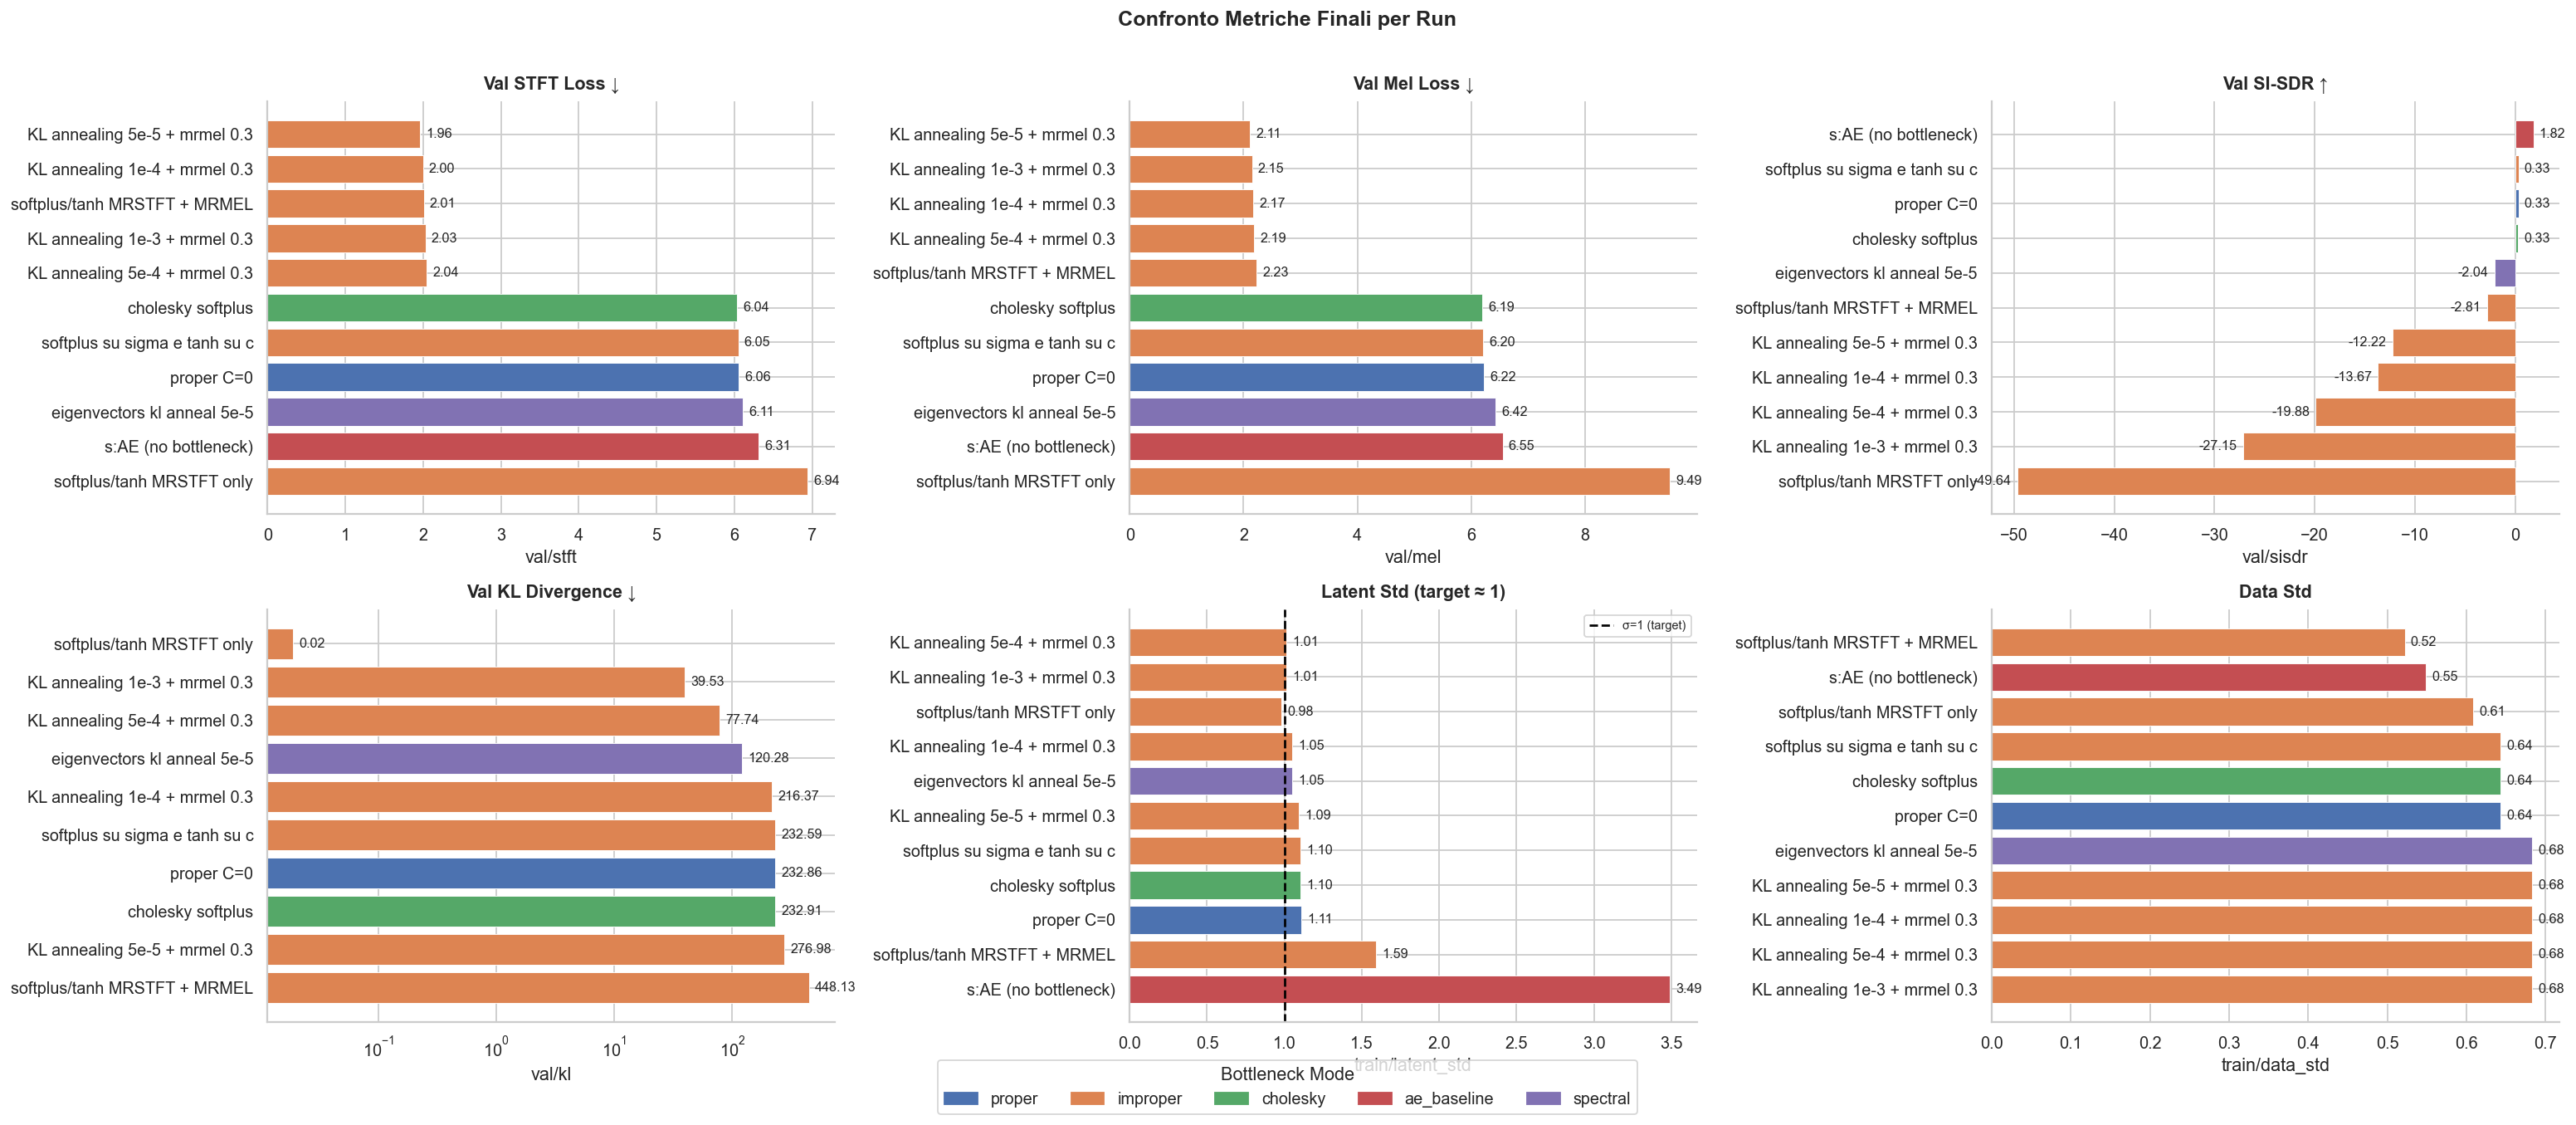

In [9]:
metrics = {
    'val/stft':         ('Val STFT Loss ↓',        True),
    'val/mel':          ('Val Mel Loss ↓',          True),
    'val/sisdr':        ('Val SI-SDR ↑',            False),
    'val/kl':           ('Val KL Divergence ↓',     True),
    'train/latent_std': ('Latent Std (target ≈ 1)', None),   # sorted by distance from 1.0
    'train/data_std':   ('Data Std',                True),
}

fig, axes = plt.subplots(2, 3, figsize=(24, 10))
axes = axes.flatten()

for ax, (metric, (label, lower_is_better)) in zip(axes, metrics.items()):
    sub = df[df[metric].notna() & ~df['short_name'].str.contains('exp|libera', case=False, na=False)].copy()


    if lower_is_better is None:
        # Sort by distance from 1.0 — closest (best) ends up at the top
        sub = sub.assign(_dist=(sub[metric] - 1.0).abs())
        sub = sub.sort_values('_dist', ascending=False)   # worst first → bottom
    else:
        sub = sub.sort_values(metric, ascending=not lower_is_better)

    bars = ax.barh(sub['short_name'], sub[metric], color=sub['color'].fillna('#777777'),
                   edgecolor='white', linewidth=0.5)
    ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=9)
    ax.set_title(label, fontweight='bold', pad=8)
    ax.set_xlabel(metric)
    ax.spines[['top', 'right']].set_visible(False)

    if metric == 'val/kl':
        ax.set_xscale('log')
    if metric == 'train/latent_std':
        ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='σ=1 (target)')
        ax.legend(fontsize=8)

handles = [mpatches.Patch(color=c, label=m) for m, c in MODE_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=5,
           title='Bottleneck Mode', bbox_to_anchor=(0.5, -0.02), frameon=True)
plt.suptitle('Confronto Metriche Finali per Run', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/summary_bar_charts.png', bbox_inches='tight')
plt.show()


## Tradeoff KL - Ricostruzione

In [8]:
sub = df[df['val/kl'].notna() & df['val/stft'].notna() & df['val/sisdr'].notna()].copy()

# --- Plot 1: KL vs STFT ---
fig1 = px.scatter(
    sub,
    x='val/kl', y='val/stft',
    color='bottleneck_mode', size='runtime_hours', size_max=35,
    hover_name='Name',
    hover_data={'epoch': True, 'kl_weight_inf': ':.1e', 'loss_label': True,
                'val/mel': ':.3f', 'val/sisdr': ':.2f', 'runtime_hours': ':.1f'},
    text='short_name',
    color_discrete_map=MODE_COLORS,
    log_x=True,
    title='Trade-off KL Divergence vs STFT MSE',
    labels={'val/kl': 'Val KL Divergence (log) ↓', 'val/stft': 'Val STFT Loss ↓'},
    template='plotly_white', width=950, height=520,
)
fig1.update_traces(textposition='top center', textfont_size=9)
fig1.add_annotation(
    x=np.log10(sub['val/kl'].min()) if sub['val/kl'].min() > 0 else 0,
    y=sub['val/stft'].min(),
    text='↙ Zona ideale', showarrow=False,
    font=dict(color='green', size=12), xref='x', yref='y',
)
fig1.show()

# --- Plot 2: KL vs SI-SDR ---
fig2 = px.scatter(
    sub,
    x='val/kl', y='val/sisdr',
    color='bottleneck_mode', size='runtime_hours', size_max=35,
    hover_name='Name',
    hover_data={'epoch': True, 'kl_weight_inf': ':.1e', 'loss_label': True,
                'val/stft': ':.3f', 'val/mel': ':.3f', 'runtime_hours': ':.1f'},
    text='short_name',
    color_discrete_map=MODE_COLORS,
    log_x=True,
    title='Trade-off KL Divergence vs SI-SDR',
    labels={'val/kl': 'Val KL Divergence (log) ↓', 'val/sisdr': 'Val SI-SDR ↑'},
    template='plotly_white', width=950, height=520,
)
fig2.update_traces(textposition='top center', textfont_size=9)
fig2.add_annotation(
    x=np.log10(sub['val/kl'].min()) if sub['val/kl'].min() > 0 else 0,
    y=sub['val/sisdr'].max(),
    text='↖ Zona ideale', showarrow=False,
    font=dict(color='green', size=12), xref='x', yref='y',
)
fig2.show()


## Full Eval Results

Merge e visualizzazione delle metriche di tutti i checkpoint in `runs/eval_full/`.

In [11]:
import pickle, zipfile, io as _io

def _epoch_from_ckpt(path):
    try:
        with zipfile.ZipFile(path) as zf:
            raw = zf.read(next(n for n in zf.namelist() if n.endswith('data.pkl')))
        class _Skip(pickle.Unpickler):
            def persistent_load(self, pid): return None
            def find_class(self, m, n):
                return (lambda *a, **kw: None) if m.startswith('torch') else super().find_class(m, n)
        return _Skip(_io.BytesIO(raw)).load().get('epoch')
    except Exception:
        return None

# ── Carica summary.csv (fonte di verità) ──────────────────────────────────────
PROJECT_ROOT = Path('/leonardo/home/userexternal/fbrigant/work/C-VAE')
EVAL_ROOT    = Path('/leonardo/home/userexternal/fbrigant/work/C-VAE/runs/eval_sweep')

df_eval = pd.read_csv(EVAL_ROOT / 'summary.csv').rename(columns={
    'si_sdr_mean':         'si_sdr',
    'stft_loss_mean':      'stft_loss',
    'clap_music_mean':     'clap_music',
    'clap_audio_mean':     'clap_audio',
    'cdpam_mean':          'cdpam',
    'fad_fadtk_mert':      'fad_mert',
    'fad_gudgud_clap-audio': 'fad_gudgud',
})

def _resolve(p):
    p = Path(p)
    return p if p.is_absolute() else PROJECT_ROOT / p

df_eval['epoch'] = df_eval['checkpoint_path'].apply(
    lambda p: _epoch_from_ckpt(_resolve(p)) if pd.notna(p) else None
)

cols = ['checkpoint', 'epoch', 'stft_loss', 'si_sdr', 'cdpam', 'clap_music', 'clap_audio', 'fad_mert', 'fad_gudgud']
df_eval = df_eval[[c for c in cols if c in df_eval.columns]].sort_values('checkpoint').reset_index(drop=True)

print(f'Loaded {len(df_eval)} checkpoints')
display(df_eval)

Loaded 13 checkpoints


,checkpoint,epoch,stft_loss,si_sdr,cdpam,clap_music,clap_audio,fad_mert,fad_gudgud
0,TESTcplx,49.0,3.308639,-34.240263,0.000258,0.088852,0.033473,17.111077,1.690038
1,TESTcplx2GPU,49.0,3.324196,-34.180657,0.000259,0.090534,0.038372,15.846302,1.677993
2,TESTreal,49.0,3.313086,-30.630982,0.000480,0.182120,0.141618,13.556152,1.298529
3,TESTreal2GPU,49.0,3.088669,-31.054386,0.000446,0.165947,0.130185,14.268343,1.331974
4,cplx64x,79.0,3.026768,-16.821177,0.000314,0.272090,0.229750,8.367673,1.038830
5,cplx_kl1e-3_ep29,29.0,3.017443,-3.344019,0.000135,0.270927,0.229565,7.202637,1.063153
6,cplx_kl1e-4_ep29,29.0,2.574383,-0.737540,0.000088,0.416319,0.402998,2.406497,0.786530
7,cplx_kl5e-4_ep29,NaN,2.736962,-1.638800,0.000099,0.337927,0.308079,4.186597,0.934804
8,cplx_kl5e-5_ep29,NaN,2.515378,-0.824169,0.000077,0.416903,0.402687,2.297127,0.785933
9,cplx_mrstft_mrmel_kl1e-4_ep79,79.0,2.172460,0.696104,0.000099,0.475368,0.479137,1.500701,0.662178


In [5]:
# ── Styled table ──────────────────────────────────────────────────────────────
METRIC_FMT = {
    'stft_loss':            ('{:.4f}', True),
    'si_sdr':               ('{:.2f}', False),
    'cdpam':                ('{:.4f}', True),
}
# Add any clap / fad columns detected
for c in df_eval.columns:
    if c.startswith('clap') and c not in METRIC_FMT:
        METRIC_FMT[c] = ('{:.4f}', True)   # CLAP sim: higher=better → lower_is_better=False
    if c.startswith('fad') and c not in METRIC_FMT:
        METRIC_FMT[c] = ('{:.2f}', True)

numeric_cols = [c for c in METRIC_FMT if c in df_eval.columns]
fmt_dict     = {c: METRIC_FMT[c][0] for c in numeric_cols}

styled_eval = (
    df_eval[['checkpoint'] + numeric_cols]
    .style
    .format(fmt_dict, na_rep='—')
    .set_caption('Full Eval — media per checkpoint (verde = migliore)')
)
# Apply gradient per metric
for col in numeric_cols:
    lower_better = METRIC_FMT[col][1]
    cmap = 'RdYlGn_r' if lower_better else 'RdYlGn'
    styled_eval = styled_eval.background_gradient(subset=[col], cmap=cmap)

display(styled_eval)


,checkpoint,stft_loss,si_sdr,cdpam,clap_music,clap_audio,fad_mert,fad_gudgud
0,TESTcplx,3.3086,-34.24,0.0003,0.0889,0.0335,17.11,1.69
1,TESTcplx2GPU,3.3242,-34.18,0.0003,0.0905,0.0384,15.85,1.68
2,TESTreal,3.3131,-30.63,0.0005,0.1821,0.1416,13.56,1.30
3,TESTreal2GPU,3.0887,-31.05,0.0004,0.1659,0.1302,14.27,1.33
4,cplx64x,3.0268,-16.82,0.0003,0.2721,0.2297,8.37,1.04
5,cplx_kl1e-3_ep29,3.0174,-3.34,0.0001,0.2709,0.2296,7.20,1.06
6,cplx_kl1e-4_ep29,2.5744,-0.74,0.0001,0.4163,0.4030,2.41,0.79
7,cplx_kl5e-4_ep29,2.7370,-1.64,0.0001,0.3379,0.3081,4.19,0.93
8,cplx_kl5e-5_ep29,2.5154,-0.82,0.0001,0.4169,0.4027,2.30,0.79
9,cplx_mrstft_mrmel_kl1e-4_ep79,2.1725,0.70,0.0001,0.4754,0.4791,1.50,0.66


In [ ]:
# ── Bar charts ────────────────────────────────────────────────────────────────
plot_metrics = [c for c in numeric_cols if df_eval[c].notna().any()]
n = len(plot_metrics)
if n == 0:
    print('Nessuna metrica da plottare.')
else:
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5 * nrows))
    axes = np.array(axes).flatten() if n > 1 else [axes]

    for ax, col in zip(axes, plot_metrics):
        sub = df_eval[['checkpoint', col]].dropna().sort_values(col)
        lower_better = METRIC_FMT.get(col, (None, True))[1]
        if not lower_better:
            sub = sub.sort_values(col, ascending=False)
        bars = ax.barh(sub['checkpoint'], sub[col], color='#4C72B0', edgecolor='white')
        ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
        direction = '↓' if lower_better else '↑'
        ax.set_title(f'{col} {direction}', fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)

    # Hide unused axes
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle('Full Eval — Confronto Checkpoint', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/full_eval_bar_charts.png', bbox_inches='tight')
    plt.show()
